# 다중 실험 결과 비교 시각화 (True Preference별 분석)

이 노트북은 experiment_date만 입력하면 해당 날짜의 모든 `*_learning.json` 파일들을 자동으로 로드해서 true_preference별로 분석하고 비교 시각화하는 기능을 제공합니다.

In [1]:
import os

os.chdir("/home/youngjins/project/belief_trading/")

import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import glob

# 스타일 설정
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

Loading experimental results by Beta and True Preference...
Loaded 54 experimental results in total.
Analysis of Seller's True Preference Inference Performance by True Preference

Total number of experiments: 54
Beta range: 0.1 ~ 3.0
True preferences: (2, 8), (4, 7), (7, 3)
Level combinations: L0B vs L1S, L1B vs L1S, L1B vs L2S

[Analysis based on Final Loss by True Preference]
                        mean      std     min      max  count
true_preference_str                                          
(2, 8)                7.7204  10.2706  0.0493  23.0259     18
(4, 7)               17.6492   5.8650  6.0745  23.0257     18
(7, 3)                3.7893   7.7128  0.0487  23.0259     18

Best performing True Preference: (7, 3) (Average Final Loss: 3.7893)
Worst performing True Preference: (4, 7) (Average Final Loss: 17.6492)

[Analysis based on Best Loss by True Preference]
                       mean     std     min     max
true_preference_str                                
(2, 8)        

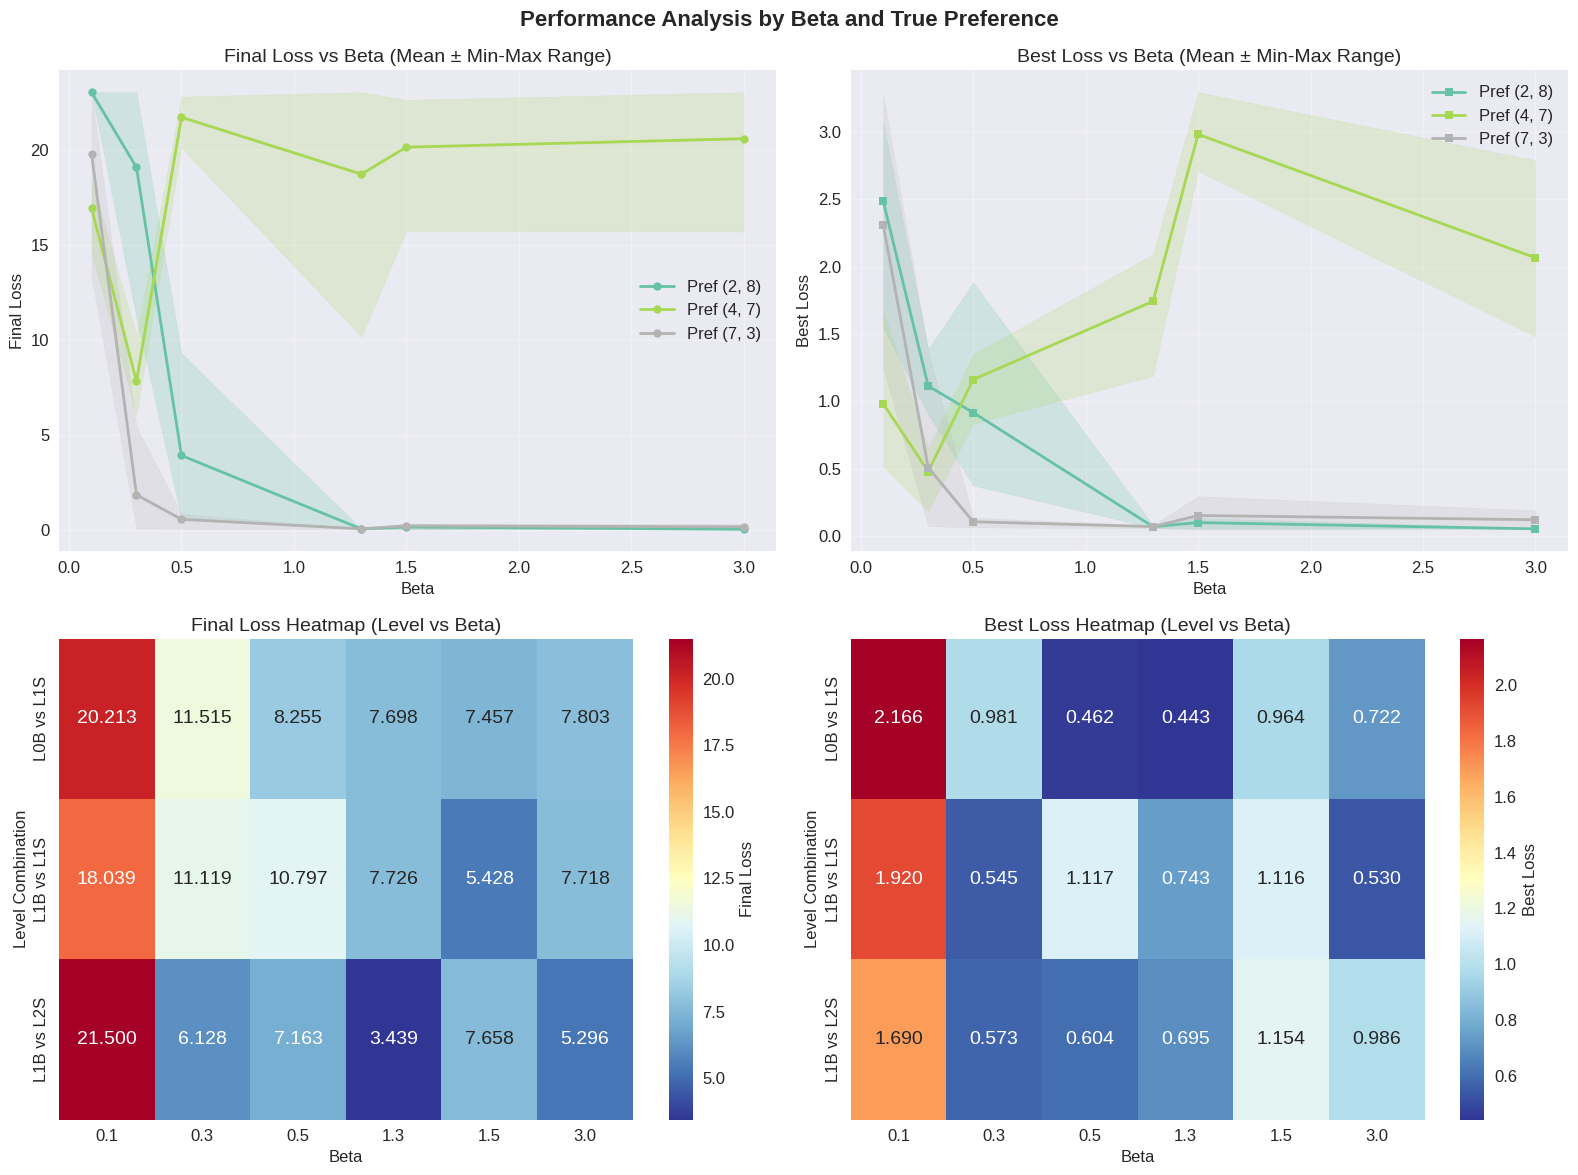

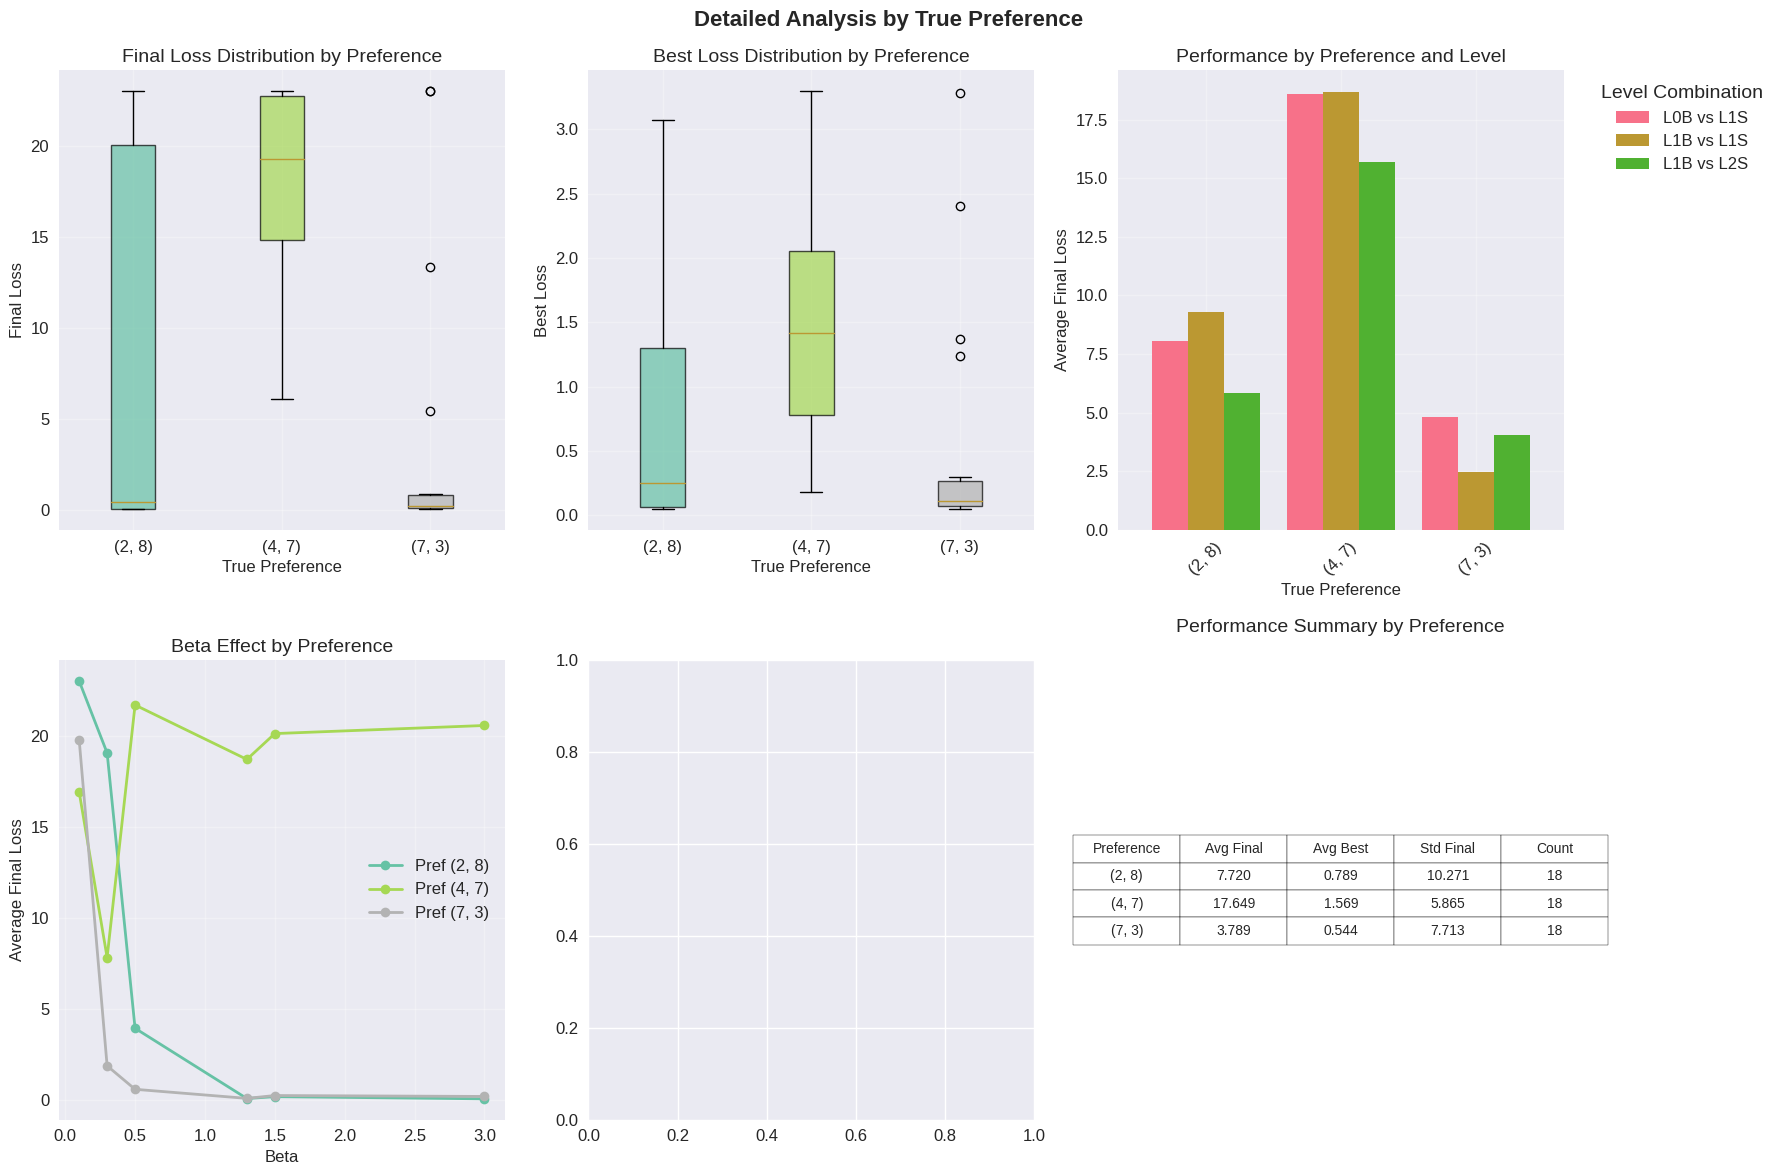

In [2]:
# 다중 실험 결과 비교를 위한 설정
results_base_dir = "./results/exp2/"
results_dir = f"{results_base_dir}/20250613_0128"  # 비교하고 싶은 실험 날짜 입력

# 파일명에서 true_preference 변환 함수
def pref_code_to_values(pref_code):
    """pref28 -> (2.0, 8.0), pref47 -> (4.0, 7.0), pref73 -> (7.0, 3.0)"""
    if pref_code == "28":
        return (2.0, 8.0)
    elif pref_code == "47":
        return (4.0, 7.0)
    elif pref_code == "73":
        return (7.0, 3.0)
    else:
        return None

def load_beta_results(results_dir):
    """
    beta별, true_preference별 실험 결과를 로드하고 정리하는 함수
    """
    all_results = []
    
    # results_dir 내의 모든 json 파일 찾기
    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    json_files.sort()
    
    for json_file in json_files:
        filename = os.path.basename(json_file)
        
        # 파일명에서 beta, preference, buyer_level, seller_level 추출
        # 예: beta1.5_pref28_L0B_vs_L1S_learning.json
        if filename.startswith("beta") and filename.endswith("_learning.json"):
            parts = filename.replace("_learning.json", "").split("_")
            
            # beta 추출
            beta_str = parts[0].replace("beta", "")
            beta = float(beta_str)
            
            # preference 추출
            pref_code = parts[1].replace("pref", "")
            true_preference_from_filename = pref_code_to_values(pref_code)
            
            # level 정보 추출
            level_info = "_".join(parts[2:])  # L0B_vs_L1S
            
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # 결과 정보 추출
                result = {
                    'beta': beta,
                    'buyer_level': data['buyer_level'],
                    'seller_level': data['seller_level'],
                    'level_combination': f"L{data['buyer_level']}B vs L{data['seller_level']}S",
                    'true_preference': tuple(data['true_preference']),
                    'true_preference_str': f"({data['true_preference'][0]:.0f}, {data['true_preference'][1]:.0f})",
                    'preference_code': pref_code,
                    'filename': filename
                }
                
                # 파일명과 데이터 내 preference 일치 확인
                if true_preference_from_filename and tuple(data['true_preference']) != true_preference_from_filename:
                    print(f"Warning: Preference mismatch in {filename}")
                    print(f"  Filename: {true_preference_from_filename}, Data: {tuple(data['true_preference'])}")
                
                # final_loss와 best_loss 정보가 있는지 확인
                if 'final_loss' in data:
                    result['final_loss'] = data['final_loss']
                if 'best_loss' in data:
                    result['best_loss'] = data['best_loss']
                if 'converged' in data:
                    result['converged'] = data['converged']
                if 'convergence_iteration' in data:
                    result['convergence_iteration'] = data['convergence_iteration']
                
                # games가 있는 경우 마지막 게임의 loss 정보 추출
                if 'games' in data and len(data['games']) > 0:
                    last_game = data['games'][-1]
                    if 'current_loss' in last_game:
                        result['final_loss'] = last_game['current_loss']
                    
                    # 모든 게임에서 최소 loss 찾기
                    losses = [game.get('current_loss', float('inf')) for game in data['games']]
                    if losses:
                        result['best_loss'] = min(losses)
                        result['total_games'] = len(data['games'])
                
                all_results.append(result)
                
            except Exception as e:
                print(f"Error loading {json_file}: {e}")
    
    return pd.DataFrame(all_results)

def plot_enhanced_preference_analysis(df):
    """
    True preference별 성능 분석 (요청된 4개 그래프)
    """
    if df.empty:
        print("데이터가 없습니다.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Performance Analysis by Beta and True Preference', fontsize=16, fontweight='bold')
    
    # 색상 설정
    colors = plt.cm.Set2(np.linspace(0, 1, len(df['true_preference_str'].unique())))
    color_map = dict(zip(df['true_preference_str'].unique(), colors))
    
    # 1. Final Loss vs Beta (by true preference)
    ax1 = axes[0, 0]
    if 'final_loss' in df.columns:
        for pref_str in sorted(df['true_preference_str'].unique()):
            pref_data = df[df['true_preference_str'] == pref_str]
            
            # Beta별 통계 계산
            stats = pref_data.groupby('beta')['final_loss'].agg(['mean', 'min', 'max']).reset_index()
            
            if not stats.empty:
                # 평균 라인 그리기
                ax1.plot(stats['beta'], stats['mean'], 
                        marker='o', label=f'Pref {pref_str}', 
                        color=color_map[pref_str], linewidth=2, markersize=6)
                
                # Min-max error bounds
                ax1.fill_between(stats['beta'], stats['min'], stats['max'], 
                               alpha=0.2, color=color_map[pref_str])
        
        ax1.set_xlabel('Beta')
        ax1.set_ylabel('Final Loss')
        ax1.set_title('Final Loss vs Beta (Mean ± Min-Max Range)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # 2. Best Loss vs Beta (by true preference)
    ax2 = axes[0, 1]
    if 'best_loss' in df.columns:
        for pref_str in sorted(df['true_preference_str'].unique()):
            pref_data = df[df['true_preference_str'] == pref_str]
            
            # Beta별 통계 계산
            stats = pref_data.groupby('beta')['best_loss'].agg(['mean', 'min', 'max']).reset_index()
            
            if not stats.empty:
                # 평균 라인 그리기
                ax2.plot(stats['beta'], stats['mean'], 
                        marker='s', label=f'Pref {pref_str}', 
                        color=color_map[pref_str], linewidth=2, markersize=6)
                
                # Min-max error bounds
                ax2.fill_between(stats['beta'], stats['min'], stats['max'], 
                               alpha=0.2, color=color_map[pref_str])
        
        ax2.set_xlabel('Beta')
        ax2.set_ylabel('Best Loss')
        ax2.set_title('Best Loss vs Beta (Mean ± Min-Max Range)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Final Loss Heatmap (Level vs Beta)
    ax3 = axes[1, 0]
    if 'final_loss' in df.columns:
        # pivot table 생성 (level combination vs beta)
        pivot_data = df.pivot_table(values='final_loss', 
                                   index='level_combination', 
                                   columns='beta', 
                                   aggfunc='mean')
        
        if not pivot_data.empty:
            sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                       ax=ax3, cbar_kws={'label': 'Final Loss'})
            ax3.set_title('Final Loss Heatmap (Level vs Beta)')
            ax3.set_xlabel('Beta')
            ax3.set_ylabel('Level Combination')
    
    # 4. Best Loss Heatmap (Level vs Beta)
    ax4 = axes[1, 1]
    if 'best_loss' in df.columns:
        # pivot table 생성 (level combination vs beta)
        pivot_data = df.pivot_table(values='best_loss', 
                                   index='level_combination', 
                                   columns='beta', 
                                   aggfunc='mean')
        
        if not pivot_data.empty:
            sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                       ax=ax4, cbar_kws={'label': 'Best Loss'})
            ax4.set_title('Best Loss Heatmap (Level vs Beta)')
            ax4.set_xlabel('Beta')
            ax4.set_ylabel('Level Combination')
    
    plt.tight_layout()
    plt.show()

def plot_preference_comparison_detailed(df):
    """
    True preference별 상세 비교 분석
    """
    if df.empty:
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Detailed Analysis by True Preference', fontsize=16, fontweight='bold')
    
    # 색상 설정
    colors = plt.cm.Set2(np.linspace(0, 1, len(df['true_preference_str'].unique())))
    color_map = dict(zip(df['true_preference_str'].unique(), colors))
    
    # 1. Final Loss Distribution by Preference
    ax1 = axes[0, 0]
    if 'final_loss' in df.columns:
        pref_order = sorted(df['true_preference_str'].unique())
        final_losses_by_pref = [df[df['true_preference_str'] == pref]['final_loss'].values for pref in pref_order]
        bp1 = ax1.boxplot(final_losses_by_pref, labels=pref_order, patch_artist=True)
        
        # 색상 적용
        for patch, pref in zip(bp1['boxes'], pref_order):
            patch.set_facecolor(color_map[pref])
            patch.set_alpha(0.7)
        
        ax1.set_xlabel('True Preference')
        ax1.set_ylabel('Final Loss')
        ax1.set_title('Final Loss Distribution by Preference')
        ax1.grid(True, alpha=0.3)
    
    # 2. Best Loss Distribution by Preference
    ax2 = axes[0, 1]
    if 'best_loss' in df.columns:
        best_losses_by_pref = [df[df['true_preference_str'] == pref]['best_loss'].values for pref in pref_order]
        bp2 = ax2.boxplot(best_losses_by_pref, labels=pref_order, patch_artist=True)
        
        # 색상 적용
        for patch, pref in zip(bp2['boxes'], pref_order):
            patch.set_facecolor(color_map[pref])
            patch.set_alpha(0.7)
        
        ax2.set_xlabel('True Preference')
        ax2.set_ylabel('Best Loss')
        ax2.set_title('Best Loss Distribution by Preference')
        ax2.grid(True, alpha=0.3)
    
    # 3. Average Performance by Preference and Level
    ax3 = axes[0, 2]
    if 'final_loss' in df.columns:
        perf_by_pref_level = df.groupby(['true_preference_str', 'level_combination'])['final_loss'].mean().unstack()
        if not perf_by_pref_level.empty:
            perf_by_pref_level.plot(kind='bar', ax=ax3, rot=45, width=0.8)
            ax3.set_xlabel('True Preference')
            ax3.set_ylabel('Average Final Loss')
            ax3.set_title('Performance by Preference and Level')
            ax3.legend(title='Level Combination', bbox_to_anchor=(1.05, 1), loc='upper left')
            ax3.grid(True, alpha=0.3)
    
    # 4. Beta Effect by Preference
    ax4 = axes[1, 0]
    if 'final_loss' in df.columns:
        for pref_str in sorted(df['true_preference_str'].unique()):
            pref_data = df[df['true_preference_str'] == pref_str]
            beta_means = pref_data.groupby('beta')['final_loss'].mean()
            
            ax4.plot(beta_means.index, beta_means.values, 
                    marker='o', label=f'Pref {pref_str}', 
                    color=color_map[pref_str], linewidth=2)
        
        ax4.set_xlabel('Beta')
        ax4.set_ylabel('Average Final Loss')
        ax4.set_title('Beta Effect by Preference')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    # 5. Convergence Rate by Preference
    ax5 = axes[1, 1]
    if 'converged' in df.columns:
        conv_rates = []
        for pref in pref_order:
            pref_data = df[df['true_preference_str'] == pref]
            if len(pref_data) > 0:
                conv_rate = pref_data['converged'].sum() / len(pref_data)
                conv_rates.append(conv_rate)
            else:
                conv_rates.append(0)
        
        bars = ax5.bar(pref_order, conv_rates, alpha=0.7)
        for bar, pref in zip(bars, pref_order):
            bar.set_color(color_map[pref])
        
        ax5.set_xlabel('True Preference')
        ax5.set_ylabel('Convergence Rate')
        ax5.set_title('Convergence Rate by Preference')
        ax5.set_ylim(0, 1)
        ax5.grid(True, alpha=0.3)
    
    # 6. Performance Summary Table
    ax6 = axes[1, 2]
    if 'final_loss' in df.columns and 'best_loss' in df.columns:
        summary_stats = []
        for pref in sorted(df['true_preference_str'].unique()):
            subset = df[df['true_preference_str'] == pref]
            stats = {
                'Preference': pref,
                'Avg Final': f"{subset['final_loss'].mean():.3f}",
                'Avg Best': f"{subset['best_loss'].mean():.3f}",
                'Std Final': f"{subset['final_loss'].std():.3f}",
                'Count': len(subset)
            }
            summary_stats.append(stats)
        
        summary_df = pd.DataFrame(summary_stats)
        ax6.axis('tight')
        ax6.axis('off')
        table = ax6.table(cellText=summary_df.values, colLabels=summary_df.columns,
                         cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax6.set_title('Performance Summary by Preference', pad=20)
    
    plt.tight_layout()
    plt.show()

def analyze_preference_effects(df):
    """
    True preference별 효과 분석
    """
    if df.empty:
        print("분석할 데이터가 없습니다.")
        return
    
    print("=" * 70)
    print("Analysis of Seller's True Preference Inference Performance by True Preference")
    print("=" * 70)
    
    # 기본 통계
    print(f"\nTotal number of experiments: {len(df)}")
    print(f"Beta range: {df['beta'].min():.1f} ~ {df['beta'].max():.1f}")
    print(f"True preferences: {', '.join(sorted(df['true_preference_str'].unique()))}")
    print(f"Level combinations: {', '.join(df['level_combination'].unique())}")
    
    # True preference별 성능 요약
    if 'final_loss' in df.columns:
        print("\n[Analysis based on Final Loss by True Preference]")
        pref_final_stats = df.groupby('true_preference_str')['final_loss'].agg(['mean', 'std', 'min', 'max', 'count'])
        print(pref_final_stats.round(4))
        
        # 최고/최악 성능 True Preference
        best_pref = df.groupby('true_preference_str')['final_loss'].mean().idxmin()
        worst_pref = df.groupby('true_preference_str')['final_loss'].mean().idxmax()
        print(f"\nBest performing True Preference: {best_pref} (Average Final Loss: {df[df['true_preference_str']==best_pref]['final_loss'].mean():.4f})")
        print(f"Worst performing True Preference: {worst_pref} (Average Final Loss: {df[df['true_preference_str']==worst_pref]['final_loss'].mean():.4f})")
    
    if 'best_loss' in df.columns:
        print("\n[Analysis based on Best Loss by True Preference]")
        pref_best_stats = df.groupby('true_preference_str')['best_loss'].agg(['mean', 'std', 'min', 'max'])
        print(pref_best_stats.round(4))
    
    # Beta별 성능 요약 (기존)
    if 'final_loss' in df.columns:
        print("\n[Analysis based on Final Loss by Beta]")
        beta_final_stats = df.groupby('beta')['final_loss'].agg(['mean', 'std', 'min', 'max', 'count'])
        print(beta_final_stats.round(4))
    
    # Level 조합별 분석
    if 'final_loss' in df.columns:
        print("\n[Performance by Level Combination]")
        level_stats = df.groupby('level_combination')['final_loss'].agg(['mean', 'std', 'count'])
        print(level_stats.round(4))
    
    # 수렴성 분석
    if 'converged' in df.columns:
        print("\n[Convergence Analysis by True Preference]")
        conv_by_pref = df.groupby('true_preference_str')['converged'].agg(['sum', 'count', 'mean'])
        conv_by_pref.columns = ['Converged', 'Total', 'Rate']
        print(conv_by_pref.round(4))
        
def main():
    # 데이터 로드
    print("Loading experimental results by Beta and True Preference...")
    df = load_beta_results(results_dir)
    
    if df.empty:
        print("No data loaded. Please check the file path and format.")
        return
    
    print(f"Loaded {len(df)} experimental results in total.")
    
    # 통계 분석
    analyze_preference_effects(df)
    
    # 시각화
    print("\nGenerating visualizations...")
    plot_enhanced_preference_analysis(df)
    plot_preference_comparison_detailed(df)
    
    return df

# 실행
df_results = main()